# IoT Sensor Data Trend Prediction — Forecasting Carbon Monoxide (CO)

**Assessment 2 — End-to-end ML pipeline on real, noisy field-sensor time-series.**

> Dataset: UCI Air Quality Dataset, collected from a field-deployed Air Quality Chemical Multisensor Device in an Italian city (March 2004 - February 2005). Original research: S. De Vito, E. Massera, M. Piga, L. Martinotto, G. Di Francia, "On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario," Sensors and Actuators B: Chemical, 2008. Source: UCI Machine Learning Repository, https://archive.ics.uci.edu/ml/datasets/Air+Quality

**Forecast task:** predict `CO(GT)` (ground-truth carbon monoxide concentration) one hour ahead, using lag and rolling-window features derived from its own history and genuinely correlated sensor channels.

---
*The six sections below match the PRD structure exactly (Data Sourcing -> Data Quality Investigation -> Data Cleaning -> Feature Engineering -> Modeling -> Evaluation and Visualization). The notebook runs top-to-bottom with no manual intervention beyond placing the CSV in ../data/.*

## 1. Data Sourcing

Load the raw CSV exactly as exported by UCI. The file is **semicolon-delimited** with **comma decimal separators** (European format, e.g. `2,6`), and each row ends with a trailing `;;` producing two empty columns. We load it raw here and verify these artifacts empirically in Section 2 — no cleaning yet.

In [1]:
import glob
import os
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Locate the dataset robustly: local /data first, then a Kaggle-style /kaggle/input fallback.
_candidates = [
    os.path.join('..', 'data', 'AirQualityUCI.csv'),
    os.path.join('data', 'AirQualityUCI.csv'),
]
_candidates += glob.glob(os.path.join('/kaggle', 'input', '**', 'AirQualityUCI.csv'), recursive=True)
DATA_PATH = next((p for p in _candidates if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError('AirQualityUCI.csv not found. Place it in ../data/ (see README).')
print('Loading from:', DATA_PATH)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

Loading from: ..\data\AirQualityUCI.csv


In [2]:
# sep=';' and decimal=',' are mandatory for this file. We do NOT yet drop anything
# or convert sentinels — this is the raw load so Section 2 can measure artifacts honestly.
df_raw = pd.read_csv(DATA_PATH, sep=';', decimal=',')
print('Raw shape (rows, cols):', df_raw.shape)
print('Total raw row count (incl. any trailing empty rows):', len(df_raw))

Raw shape (rows, cols): (9471, 17)
Total raw row count (incl. any trailing empty rows): 9471


In [3]:
print('Columns as loaded:')
print(list(df_raw.columns))
print()
print('Dtypes:')
print(df_raw.dtypes)

Columns as loaded:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Dtypes:
Date                 str
Time                 str
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object


In [4]:
df_raw.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
df_raw.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# describe() on raw data — note: -200 sentinels and the empty columns are still present,
# so these statistics are intentionally 'dirty'. They are a baseline, not the cleaned truth.
df_raw.describe(include='all')

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
unique,391,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,11/03/2004,18.00.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,24,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,NaN,NaN,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,NaN,NaN,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,NaN,NaN,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,NaN,NaN,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,NaN,NaN,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN


## 2. Data Quality Investigation

Empirically verify each data-quality claim from the PRD against the actually loaded file. **No cleaning is performed in this section** — every check below only measures and reports. Cleaning happens in Phase 2, driven by what we find here.

Six checks:
1. CSV export-artifact columns (`Unnamed: 15`, `Unnamed: 16`) — present and fully empty?
2. Trailing fully-empty rows — how many?
3. `-200` sentinel values — count per column.
4. `NMHC(GT)` missing rate after sentinel conversion — above 90%?
5. Hourly timestamp gaps (PRD hypothesis, **not** pre-confirmed) — contiguous or not?
6. Exact column names as loaded.

### Check 1 — CSV export-artifact columns

In [7]:
unnamed_cols = [c for c in df_raw.columns if str(c).startswith('Unnamed')]
print('Unnamed columns present:', unnamed_cols)
for c in unnamed_cols:
    print(f'  {c!r}: non-null count = {df_raw[c].notna().sum()}, fully empty = {df_raw[c].isna().all()}')

Unnamed columns present: ['Unnamed: 15', 'Unnamed: 16']
  'Unnamed: 15': non-null count = 0, fully empty = True
  'Unnamed: 16': non-null count = 0, fully empty = True


### Check 2 — Trailing fully-empty rows
Rows that are entirely `NaN` across every column. These are a CSV export-tail artifact, distinct from the `-200` sentinel and from any genuine timestamp gap.

In [8]:
all_nan_mask = df_raw.isna().all(axis=1)
n_all_nan = int(all_nan_mask.sum())
print('Rows that are fully NaN across every column:', n_all_nan)
print('Are they all contiguous at the tail?',
      bool(all_nan_mask.iloc[len(df_raw) - n_all_nan:].all()) if n_all_nan else 'n/a')
print('\nIndex positions of fully-empty rows (first/last few):')
print(df_raw.index[all_nan_mask].tolist()[:3], '...', df_raw.index[all_nan_mask].tolist()[-3:])
print('\nNon-empty data rows (len - trailing empties):', len(df_raw) - n_all_nan)

Rows that are fully NaN across every column: 114
Are they all contiguous at the tail? True

Index positions of fully-empty rows (first/last few):
[9357, 9358, 9359] ... [9468, 9469, 9470]

Non-empty data rows (len - trailing empties): 9357


### Check 3 — `-200` sentinel values per column
Missing/invalid readings are encoded as the literal `-200`, not `NaN`. Count occurrences per numeric column on the raw data (before any conversion).

In [9]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
sentinel_counts = (df_raw[numeric_cols] == -200).sum().sort_values(ascending=False)
n_data_rows = len(df_raw) - n_all_nan
sentinel_table = pd.DataFrame({
    'sentinel_-200_count': sentinel_counts,
    'pct_of_data_rows': (sentinel_counts / n_data_rows * 100).round(2),
})
print(f'-200 counts per numeric column (pct relative to {n_data_rows} non-empty data rows):')
sentinel_table

-200 counts per numeric column (pct relative to 9357 non-empty data rows):


,sentinel_-200_count,pct_of_data_rows
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
PT08.S1(CO),366,3.91
PT08.S2(NMHC),366,3.91
C6H6(GT),366,3.91
PT08.S3(NOx),366,3.91
PT08.S4(NO2),366,3.91
PT08.S5(O3),366,3.91


### Check 4 — `NMHC(GT)` missing rate
After treating `-200` as missing, what fraction of real data rows is `NMHC(GT)` missing? PRD claim: > 90%, making the column unusable.

In [10]:
nmhc = df_raw['NMHC(GT)'].iloc[:n_data_rows]  # exclude trailing empty rows
nmhc_missing = int((nmhc == -200).sum() + nmhc.isna().sum())
nmhc_rate = nmhc_missing / n_data_rows * 100
print(f'NMHC(GT) missing (==-200 or NaN): {nmhc_missing} / {n_data_rows} rows = {nmhc_rate:.2f}%')
print('Above 90% (PRD claim)?', nmhc_rate > 90)

NMHC(GT) missing (==-200 or NaN): 8443 / 9357 rows = 90.23%
Above 90% (PRD claim)? True


### Check 5 — Hourly timestamp gaps (hypothesis, not pre-confirmed)
Parse `Date` + `Time` into a single datetime over the non-empty rows, sort, and compare against a strict hourly grid spanning the same range. This distinguishes genuine missing timestamps from the `-200` sentinel and from the trailing empty rows.

In [11]:
# Work on the non-empty data rows only. Date is dd/mm/yyyy; Time is HH.MM.SS.
valid = df_raw.iloc[:n_data_rows].copy()
dt = pd.to_datetime(
    valid['Date'] + ' ' + valid['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce',
)
n_unparsed = int(dt.isna().sum())
print('Unparseable datetimes among data rows:', n_unparsed)

dt_sorted = dt.sort_values()
print('Range:', dt_sorted.iloc[0], '->', dt_sorted.iloc[-1])
print('Duplicate timestamps:', int(dt_sorted.duplicated().sum()))

expected = pd.date_range(dt_sorted.iloc[0], dt_sorted.iloc[-1], freq='h')
actual = pd.DatetimeIndex(dt_sorted.unique())
missing_ts = expected.difference(actual)

print('\nTimestamps present (unique data rows):', len(actual))
print('Timestamps expected on a strict hourly grid:', len(expected))
print('Genuine missing hourly timestamps:', len(missing_ts))
if len(missing_ts):
    print('First few missing:', list(missing_ts[:5]))

Unparseable datetimes among data rows: 0


Range: 2004-03-10 18:00:00 -> 2005-04-04 14:00:00
Duplicate timestamps: 0

Timestamps present (unique data rows): 9357
Timestamps expected on a strict hourly grid: 9357
Genuine missing hourly timestamps: 0


In [12]:
# If gaps exist, characterise their run lengths (consecutive missing hours).
if len(missing_ts):
    s = pd.Series(missing_ts)
    breaks = (s.diff() != pd.Timedelta(hours=1)).cumsum()
    run_lengths = s.groupby(breaks).size()
    print('Number of distinct gap runs:', run_lengths.nunique() if False else len(run_lengths))
    print('Gap-run length distribution (hours -> how many such runs):')
    print(run_lengths.value_counts().sort_index())
    print('\nLongest single gap (hours):', int(run_lengths.max()))
else:
    print('No genuine hourly gaps: the valid date range is fully contiguous.')

No genuine hourly gaps: the valid date range is fully contiguous.


### Check 6 — Exact column names as loaded
Report what `.columns` actually returns — no renaming assumptions.

In [13]:
for i, c in enumerate(df_raw.columns):
    print(f'{i:2d}: {c!r}')

 0: 'Date'
 1: 'Time'
 2: 'CO(GT)'
 3: 'PT08.S1(CO)'
 4: 'NMHC(GT)'
 5: 'C6H6(GT)'
 6: 'PT08.S2(NMHC)'
 7: 'NOx(GT)'
 8: 'PT08.S3(NOx)'
 9: 'NO2(GT)'
10: 'PT08.S4(NO2)'
11: 'PT08.S5(O3)'
12: 'T'
13: 'RH'
14: 'AH'
15: 'Unnamed: 15'
16: 'Unnamed: 16'


### 2.7 Visualizing the data-quality issues
The numbers above are made concrete by two plots: the raw target signal with its dropouts, and where missingness concentrates across the sensor array over time.

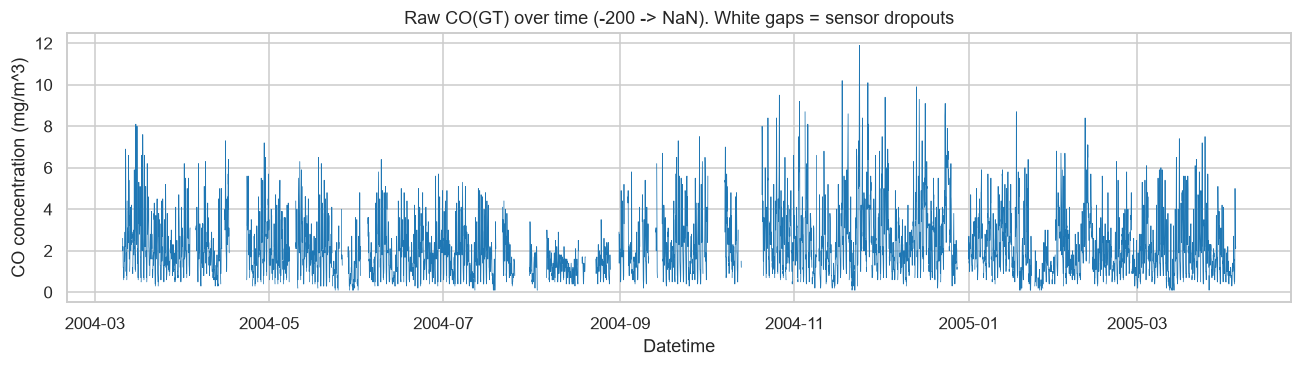

In [14]:
# Raw CO(GT) over time (-200 shown as gaps). Reuses `valid` and `dt` from Check 5.
co_raw = valid['CO(GT)'].replace(-200, np.nan).copy()
co_raw.index = pd.DatetimeIndex(dt.values)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(co_raw.index, co_raw.values, lw=0.5, color='tab:blue')
ax.set_title('Raw CO(GT) over time (-200 -> NaN). White gaps = sensor dropouts')
ax.set_xlabel('Datetime'); ax.set_ylabel('CO concentration (mg/m^3)')
plt.tight_layout(); plt.show()

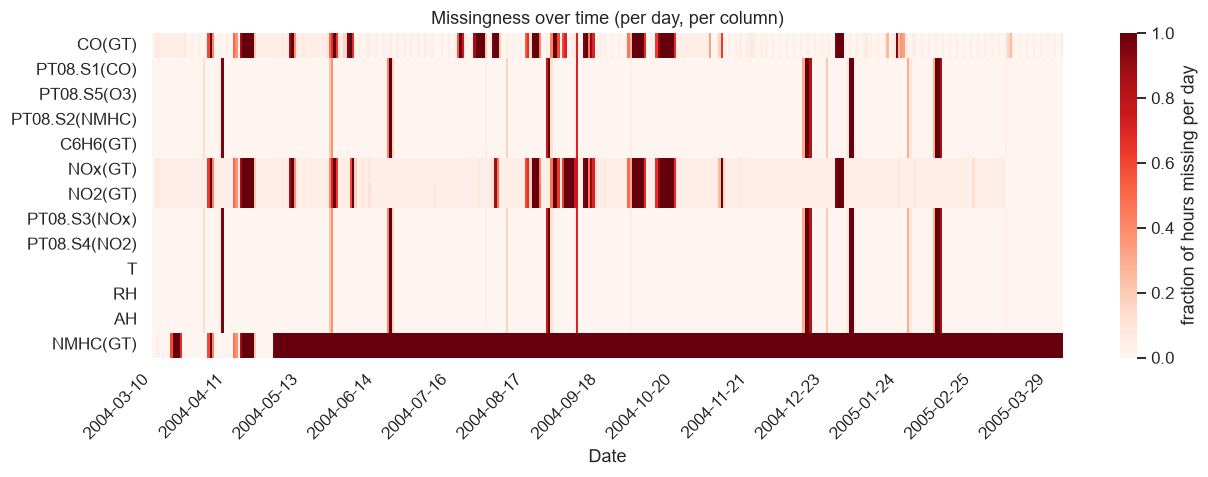

In [15]:
# Missingness-by-day heatmap across columns: fraction of each day's hours missing.
cols_miss = ['CO(GT)','PT08.S1(CO)','PT08.S5(O3)','PT08.S2(NMHC)','C6H6(GT)',
             'NOx(GT)','NO2(GT)','PT08.S3(NOx)','PT08.S4(NO2)','T','RH','AH','NMHC(GT)']
miss = ((valid[cols_miss] == -200) | valid[cols_miss].isna())
miss.index = pd.DatetimeIndex(dt.values)
daily_miss = miss.resample('D').mean()
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(daily_miss.T, cmap='Reds', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'fraction of hours missing per day'})
step = max(1, len(daily_miss)//12)
ax.set_xticks(np.arange(0, len(daily_miss), step))
ax.set_xticklabels([daily_miss.index[i].strftime('%Y-%m-%d') for i in range(0, len(daily_miss), step)],
                   rotation=45, ha='right')
ax.set_title('Missingness over time (per day, per column)')
ax.set_xlabel('Date'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

Two things stand out and corroborate the earlier counts: `NMHC(GT)` is almost entirely red (90%+ missing, hence excluded), and the long blackouts hit the whole sensor array **simultaneously** - the device dropped out as a unit, not channel-by-channel. That synchronized, multi-day pattern is exactly why those long gaps are left as `NaN` rather than interpolated.

## 3. Data Cleaning

Every step below is driven by the **Phase 1 / Phase 2 evidence**, not by assumption. Steps are applied in order, each preceded by the decision and the evidence behind it.

**Cleaning plan (from the investigation):**
1. Drop artifact columns `Unnamed: 15`, `Unnamed: 16` (confirmed 0 non-null).
2. Drop the **114** trailing fully-empty rows (`dropna(how='all')`).
3. Parse `Date` + `Time` -> single sorted `DatetimeIndex` (hourly).
4. Convert all `-200` sentinels to `NaN` across numeric columns.
5. Exclude `NMHC(GT)` (90.23% missing -> unusable).
6. Timestamp gaps: **none found** in Phase 1 (series is contiguous) -> no index reindexing needed.
7. Impute **short** within-row NaN gaps only; leave **long** gaps as `NaN`.

### Step 1 - Drop CSV export-artifact columns
`Unnamed: 15` and `Unnamed: 16` were confirmed fully empty (0 non-null) in Phase 1.

In [16]:
df = df_raw.copy()
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
print('Dropped artifact columns. Shape now:', df.shape)

Dropped artifact columns. Shape now: (9471, 15)


### Step 2 - Drop trailing fully-empty rows
Phase 1 found **114** rows that are `NaN` across every column - a CSV export-tail artifact, not real missing data.

In [17]:
before = len(df)
df = df.dropna(how='all')
after = len(df)
print(f'Dropped {before - after} fully-empty rows ({before} -> {after}).')
assert after == 9357, 'Expected 9357 real data rows'

Dropped 114 fully-empty rows (9471 -> 9357).


### Step 3 - Build a sorted hourly DatetimeIndex
`Date` is `dd/mm/yyyy`, `Time` is `HH.MM.SS`. Combine into one timestamp, set as the index, sort ascending. Phase 1 confirmed 0 unparseable datetimes and 0 duplicates.

In [18]:
dt = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df = df.drop(columns=['Date', 'Time']).set_index(dt).sort_index()
df.index.name = 'Datetime'
print('Index monotonic increasing:', df.index.is_monotonic_increasing)
print('Range:', df.index.min(), '->', df.index.max())
# Re-confirm contiguity directly on the built index (Phase 1 hypothesis check, re-verified here).
full = pd.date_range(df.index.min(), df.index.max(), freq='h')
print('Missing hourly timestamps vs strict grid:', len(full.difference(df.index)))

Index monotonic increasing: True
Range: 2004-03-10 18:00:00 -> 2005-04-04 14:00:00
Missing hourly timestamps vs strict grid: 0


### Step 4 - Convert `-200` sentinels to `NaN`
`-200` encodes a missing/invalid reading. Treating it as a real value would poison every statistic and the model's loss (note the impossible negative means in the raw `describe()`). Convert across all numeric columns.

In [19]:
neg200_before = int((df == -200).sum().sum())
df = df.replace(-200, np.nan)
neg200_after = int((df == -200).sum().sum())
print(f'-200 occurrences: {neg200_before} -> {neg200_after}')
assert neg200_after == 0, 'No -200 should remain'

-200 occurrences: 16701 -> 0


### Step 5 - Exclude `NMHC(GT)`
Phase 1 measured `NMHC(GT)` at **90.23%** missing after sentinel conversion. Imputing 90%+ of a column manufactures signal that was never measured; this is independently documented for this dataset. We **exclude** it entirely - not as a feature, not as a target.

In [20]:
df = df.drop(columns=['NMHC(GT)'])
print('Excluded NMHC(GT). Remaining columns:', list(df.columns))

Excluded NMHC(GT). Remaining columns: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


### Step 6 - Timestamp gaps
Phase 1's hypothesis test found the valid date range is **fully contiguous** (9,357 present = 9,357 expected hourly slots, 0 missing). Re-confirmed in Step 3 above. **No index reindexing or gap-filling of the time axis is required** - we state this plainly rather than inflate a missing-timestamps narrative. The remaining missingness is *within-row* values (the `-200`->NaN conversions), handled next.

### Step 7 - Within-row NaN: gap-aware imputation
The missingness here is **bimodal**, which dictates the strategy:

| Column | NaN % | Gap structure |
|---|---|---|
| `CO(GT)` (target) | 17.99% | 145/187 runs are 1h, but 18 runs > 24h (max **173h ~ 7 days**) |
| `PT08.S1(CO)` | 3.91% | mostly long runs (median 9h, max 76h) |
| `T` | 3.91% | identical pattern (sensors blacked out together) |

**Decision:** linear (time-based) interpolation for **short gaps only (<= 2 hours)**; leave longer gaps as `NaN`. A pollutant concentration varies smoothly over 1-2 hours, so interpolating a short dropout is a faithful reconstruction. Interpolating a multi-day blackout would *fabricate* up to a week of CO readings and corrupt both training labels and evaluation - so those rows are deliberately left `NaN` and dropped at feature-construction time in Phase 3.

In [21]:
# Quantify consecutive-NaN run lengths per modeling column (evidence for the decision).
def nan_run_lengths(s):
    is_na = s.isna()
    run_id = (is_na != is_na.shift()).cumsum()
    sizes = is_na.groupby(run_id).transform('size').where(is_na)
    # collapse to one length per run
    runs = sizes.dropna().groupby(run_id).first()
    return runs.astype(int)

for col in ['CO(GT)', 'PT08.S1(CO)', 'T']:
    r = nan_run_lengths(df[col])
    print(f'{col:14s} NaN={int(df[col].isna().sum()):5d} ({df[col].isna().mean()*100:5.2f}%) '
          f'runs={len(r):3d} max={int(r.max()) if len(r) else 0:3d}h '
          f'<=2h_runs={int((r<=2).sum())} >24h_runs={int((r>24).sum())}')

CO(GT)         NaN= 1683 (17.99%) runs=187 max=173h <=2h_runs=154 >24h_runs=18
PT08.S1(CO)    NaN=  366 ( 3.91%) runs= 16 max= 76h <=2h_runs=3 >24h_runs=5
T              NaN=  366 ( 3.91%) runs= 16 max= 76h <=2h_runs=3 >24h_runs=5


In [22]:
MAX_GAP = 2  # hours: interpolate runs this short or shorter; leave longer runs as NaN

def interpolate_short_gaps(s, max_gap=MAX_GAP):
    is_na = s.isna()
    run_id = (is_na != is_na.shift()).cumsum()
    run_len = is_na.groupby(run_id).transform('size')
    interp = s.interpolate(method='time', limit_direction='both')
    fill_mask = is_na & (run_len <= max_gap)
    out = s.copy()
    out[fill_mask] = interp[fill_mask]
    return out

num_cols = df.columns  # all remaining columns are numeric
nan_before = df.isna().sum()
df[num_cols] = df[num_cols].apply(interpolate_short_gaps)
nan_after = df.isna().sum()

summary = pd.DataFrame({
    'nan_before': nan_before,
    'nan_after': nan_after,
    'short_gaps_filled': nan_before - nan_after,
    'pct_nan_remaining': (nan_after / len(df) * 100).round(2),
})
print(f'Short-gap (<= {MAX_GAP}h) interpolation applied. Long gaps deliberately left as NaN.')
summary

Short-gap (<= 2h) interpolation applied. Long gaps deliberately left as NaN.


,nan_before,nan_after,short_gaps_filled,pct_nan_remaining
CO(GT),1683,1520,163,16.24
PT08.S1(CO),366,363,3,3.88
C6H6(GT),366,363,3,3.88
PT08.S2(NMHC),366,363,3,3.88
NOx(GT),1639,1314,325,14.04
PT08.S3(NOx),366,363,3,3.88
NO2(GT),1642,1316,326,14.06
PT08.S4(NO2),366,363,3,3.88
PT08.S5(O3),366,363,3,3.88
T,366,363,3,3.88


### Cleaned-data verification
Confirm the cleaned frame is well-formed before feature engineering.

In [23]:
print('Cleaned shape:', df.shape)
print('Index monotonic increasing:', df.index.is_monotonic_increasing)
print('Any -200 remaining:', int((df == -200).sum().sum()))
print('Columns:', list(df.columns))
print()
print('NaN rate per column (remaining long-gap NaNs, dropped in Phase 3):')
print((df.isna().mean() * 100).round(2).astype(str) + ' %')
df.head()

Cleaned shape: (9357, 12)
Index monotonic increasing: True
Any -200 remaining: 0
Columns: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

NaN rate per column (remaining long-gap NaNs, dropped in Phase 3):
CO(GT)           16.24 %
PT08.S1(CO)       3.88 %
C6H6(GT)          3.88 %
PT08.S2(NMHC)     3.88 %
NOx(GT)          14.04 %
PT08.S3(NOx)      3.88 %
NO2(GT)          14.06 %
PT08.S4(NO2)      3.88 %
PT08.S5(O3)       3.88 %
T                 3.88 %
RH                3.88 %
AH                3.88 %
dtype: str


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## 4. Feature Engineering

We forecast `CO(GT)` **one hour ahead**. For a row at time *t*, the target is `CO[t+1]` and every feature uses only information available **at or before *t*** - this is the leakage guard, made explicit below.

Feature families:
- **Autoregressive history** of CO: the current reading `CO[t]` plus lags `t-1, t-2, t-3`.
- **Rolling 24h** mean and std of CO (one full diurnal cycle).
- **Co-located device sensor channels** at *t*, gated by a correlation check.
- **Calendar** features (hour-of-day, day-of-week) for the diurnal/weekly pollution cycle.

### 4.1 Correlation check - which sensor channels earn a place
The PRD anticipated `PT08.S1(CO)` and `T` as candidates. We verify on the cleaned data rather than assume.

In [24]:
corr_co = df.corr(numeric_only=True)['CO(GT)'].drop('CO(GT)').sort_values(ascending=False)
print('Pearson correlation of each column with CO(GT) (cleaned data):')
corr_co.round(3).to_frame('corr_with_CO')

Pearson correlation of each column with CO(GT) (cleaned data):


,corr_with_CO
C6H6(GT),0.931
PT08.S2(NMHC),0.916
PT08.S1(CO),0.881
PT08.S5(O3),0.855
NOx(GT),0.801
NO2(GT),0.697
PT08.S4(NO2),0.633
AH,0.050
RH,0.038
T,0.031


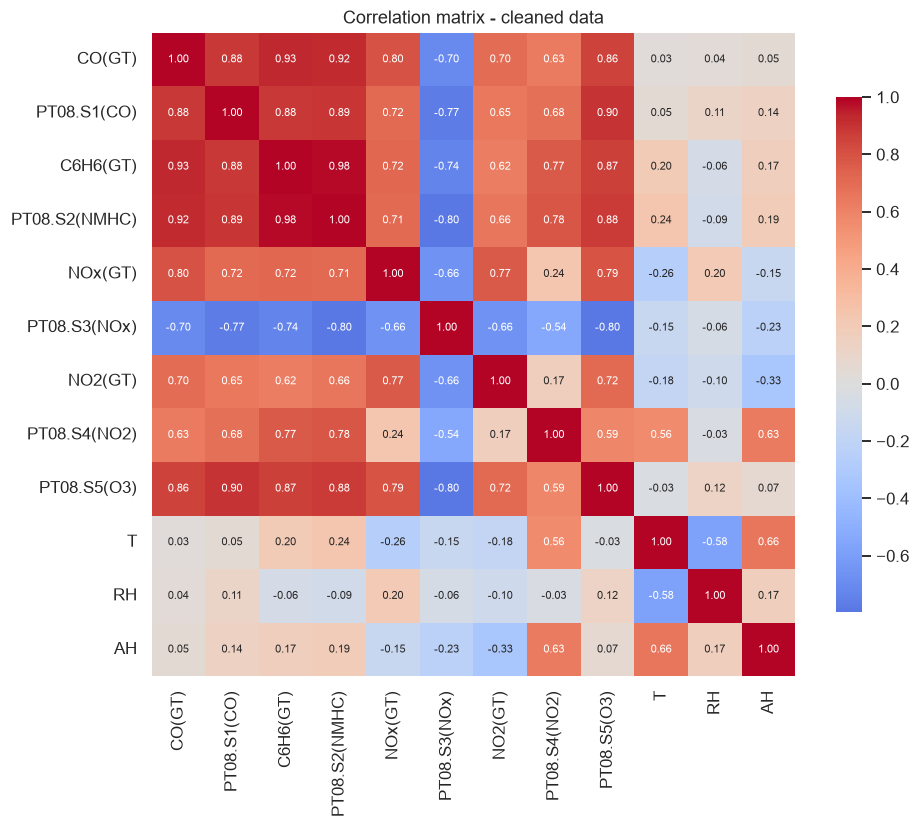

In [25]:
# Visual companion to the numeric correlations above.
corr_mat = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, annot_kws={'size': 7}, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation matrix - cleaned data')
plt.tight_layout(); plt.show()

**Decision from the correlations:**
- **Include** the device's own sensor channels that correlate strongly: `PT08.S2(NMHC)` (0.92), `PT08.S1(CO)` (0.88), `PT08.S5(O3)` (0.86). These are the electronic nose's raw responses at time *t* - genuinely available at prediction time and physically related to CO.
- **Exclude `T` (temperature).** Its correlation with CO is **0.031** - effectively zero, contradicting the PRD's anticipated "moderate" relationship. Per the brief's own instruction, we do not force an anticipated feature that the data does not support. `RH` (0.04) and `AH` (0.05) are dropped for the same reason.
- We deliberately use the **device sensor channels (`PT08.*`)** rather than the co-located reference-analyzer columns (`NOx(GT)`, `NO2(GT)`, `C6H6(GT)`), keeping the narrative clean: *forecast near-future CO from the IoT device's own sensor array plus CO history.*

### 4.1b Temporal structure - why `hour`, `dow`, and a 24h window
CO is a traffic-driven pollutant, so it should show a strong daily rhythm. Confirming that justifies the calendar features and the 24-hour rolling window.

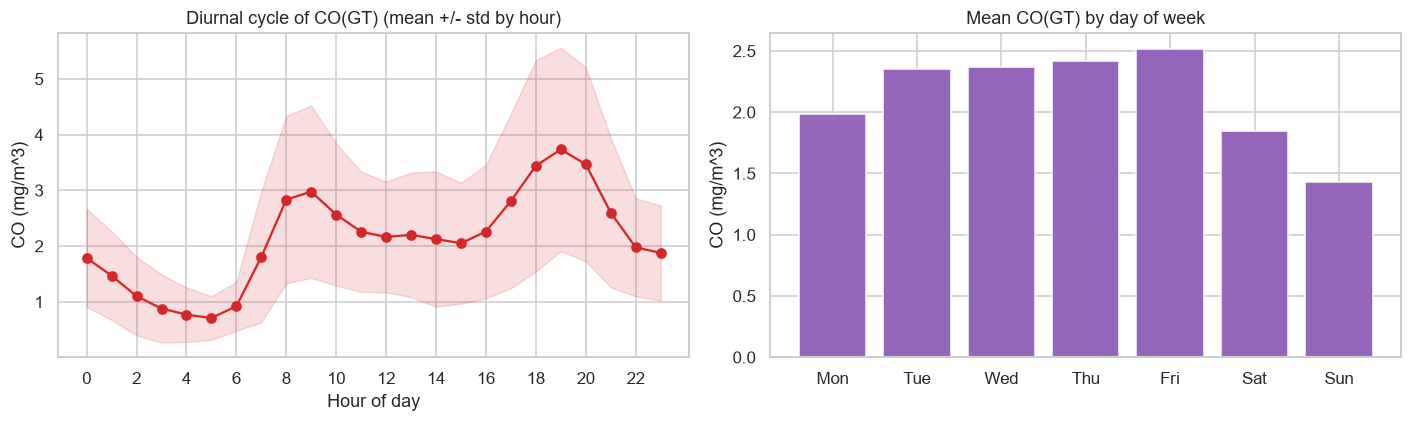

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hourly = df['CO(GT)'].groupby(df.index.hour).agg(['mean', 'std'])
axes[0].plot(hourly.index, hourly['mean'], marker='o', color='tab:red')
axes[0].fill_between(hourly.index, hourly['mean']-hourly['std'], hourly['mean']+hourly['std'],
                     alpha=0.15, color='tab:red')
axes[0].set_title('Diurnal cycle of CO(GT) (mean +/- std by hour)')
axes[0].set_xlabel('Hour of day'); axes[0].set_ylabel('CO (mg/m^3)'); axes[0].set_xticks(range(0,24,2))

dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df['CO(GT)'].groupby(df.index.dayofweek).mean()
axes[1].bar(range(7), dow.values, color='tab:purple')
axes[1].set_title('Mean CO(GT) by day of week')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dow_names); axes[1].set_ylabel('CO (mg/m^3)')
plt.tight_layout(); plt.show()

The diurnal curve shows the expected twin rush-hour peaks (morning and evening) with an overnight trough - a clear 24-hour cycle, which is why the rolling window is set to 24 and why `hour` carries real signal (importance ~0.09 in the final model). The weekday/weekend contrast is milder but visible (lower weekend CO), supporting `dow` as a light secondary feature.

### 4.2 Build the feature matrix

In [27]:
co = df['CO(GT)']
feat = pd.DataFrame(index=df.index)

# Target: CO one hour ahead.
feat['CO_t1'] = co.shift(-1)

# Autoregressive CO history (current reading + 3 lags).
feat['CO_current'] = co            # value at t  (available when predicting t+1)
feat['CO_lag1']    = co.shift(1)   # t-1
feat['CO_lag2']    = co.shift(2)   # t-2
feat['CO_lag3']    = co.shift(3)   # t-3

# Rolling 24h stats: window ends at t, so it uses CO[t-23 .. t] only.
# min_periods=12 -> require at least half a day present before emitting a value,
# trading a little coverage for a stable daily statistic (avoids means built from 1-2 points).
feat['CO_roll24_mean'] = co.rolling(24, min_periods=12).mean()
feat['CO_roll24_std']  = co.rolling(24, min_periods=12).std()

# Strongly-correlated device sensor channels at time t.
feat['PT08_S1_CO']   = df['PT08.S1(CO)']
feat['PT08_S5_O3']   = df['PT08.S5(O3)']
feat['PT08_S2_NMHC'] = df['PT08.S2(NMHC)']

# Calendar features for the diurnal / weekly cycle.
feat['hour'] = df.index.hour
feat['dow']  = df.index.dayofweek

FEATURES = ['CO_current','CO_lag1','CO_lag2','CO_lag3','CO_roll24_mean','CO_roll24_std',
            'PT08_S1_CO','PT08_S5_O3','PT08_S2_NMHC','hour','dow']
print('Target: CO_t1  |  #features:', len(FEATURES))
feat.head()

Target: CO_t1  |  #features: 11


,CO_t1,CO_current,CO_lag1,CO_lag2,CO_lag3,CO_roll24_mean,CO_roll24_std,PT08_S1_CO,PT08_S5_O3,PT08_S2_NMHC,hour,dow
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.0,2.6,NaN,NaN,NaN,NaN,NaN,1360.0,1268.0,1046.0,18,2
2004-03-10 19:00:00,2.2,2.0,2.6,NaN,NaN,NaN,NaN,1292.0,972.0,955.0,19,2
2004-03-10 20:00:00,2.2,2.2,2.0,2.6,NaN,NaN,NaN,1402.0,1074.0,939.0,20,2
2004-03-10 21:00:00,1.6,2.2,2.2,2.0,2.6,NaN,NaN,1376.0,1203.0,948.0,21,2
2004-03-10 22:00:00,1.2,1.6,2.2,2.2,2.0,NaN,NaN,1272.0,1110.0,836.0,22,2


### 4.3 Leakage check (explicit)

Every predictor for row *t* is computed from data at *t* or earlier; the only forward-looking column is the **label** `CO_t1 = CO[t+1]`, which is never used as an input.

| Feature | Time basis | Known at *t*? |
|---|---|---|
| `CO_current` | `CO[t]` | yes |
| `CO_lag1/2/3` | `CO[t-1..t-3]` | yes |
| `CO_roll24_mean/std` | `CO[t-23..t]` | yes |
| `PT08_S1_CO`, `PT08_S5_O3`, `PT08_S2_NMHC` | sensor reading at `t` | yes |
| `hour`, `dow` | timestamp of `t` | yes (deterministic) |
| **`CO_t1`** (target) | `CO[t+1]` | **label only - never an input** |

No rolling or lag window reaches forward, so the 1-hour-ahead setup is leakage-free.

In [28]:
before = len(feat)
model_df = feat.dropna()   # removes warm-up rows (first lags/rolling) AND long-gap NaN rows from Phase 2
after = len(model_df)
print(f'Rows before dropna: {before}  ->  after: {after}  (dropped {before-after})')
print('Modeling window:', model_df.index.min(), '->', model_df.index.max())

Rows before dropna: 9357  ->  after: 7192  (dropped 2165)
Modeling window: 2004-03-11 05:00:00 -> 2005-04-04 13:00:00


## 5. Modeling

The brief invites several model families (trend-regression, ensembles, sequential nets). Rather than commit to one model up front, we **train a diverse panel and let the data choose**, using a selection protocol that is itself an overfitting guard.

**Selection protocol**
1. **Candidates (diverse by design):** `LinearRegression` and `Ridge` (linear trend-regression, scaled), `RandomForest` (bagged trees), `GradientBoosting` and `HistGradientBoosting` (boosted trees). Linear models are wrapped in a `StandardScaler` pipeline; tree models need no scaling.
2. **Selection by TimeSeriesSplit cross-validation on the *training set only*.** We rank models by mean CV RMSE over 5 expanding-window folds. Crucially we **never look at the test set to choose** - that would leak model-selection information.
3. **Single final evaluation:** the CV winner is refit on the full training set and scored **once** on the held-out chronological test set. That number is the honest generalization estimate.

Hyperparameters for the tree models are deliberately regularized (shallow depth, low learning rate, subsampling, leaf floors) for the reasons discussed after the results.

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Chronological split - NO shuffling (shuffling would leak future timestamps into training).
n = len(model_df); split = int(n * 0.8)
X = model_df[FEATURES]; y = model_df['CO_t1']
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f'Train: {len(X_train)} rows  |  {X_train.index.min()} -> {X_train.index.max()}')
print(f'Test : {len(X_test)} rows  |  {X_test.index.min()} -> {X_test.index.max()}')

# Persistence baseline for context: predict CO[t+1] = CO[t].
base_rmse = root_mean_squared_error(y_test, X_test['CO_current'])
base_mae  = mean_absolute_error(y_test, X_test['CO_current'])
print(f'\nPersistence baseline (yhat = CO_current): test RMSE={base_rmse:.3f}  MAE={base_mae:.3f}')

Train: 5753 rows  |  2004-03-11 05:00:00 -> 2005-01-30 16:00:00
Test : 1439 rows  |  2005-01-30 17:00:00 -> 2005-04-04 13:00:00

Persistence baseline (yhat = CO_current): test RMSE=0.792  MAE=0.513


### 5.1 Cross-validated model selection
`TimeSeriesSplit` produces 5 expanding-window folds (train always precedes validation in time), so CV respects temporal order exactly like the final split does.

In [30]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

candidates = {
    'LinearRegression':     make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge':                make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'RandomForest':         RandomForestRegressor(n_estimators=300, max_depth=12,
                                                  min_samples_leaf=2, random_state=42, n_jobs=-1),
    'GradientBoosting':     GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                                      subsample=0.8, min_samples_leaf=20, random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=400, max_depth=3, learning_rate=0.05,
                                                          l2_regularization=1.0, random_state=42),
}

tscv = TimeSeriesSplit(n_splits=5)
rows = []
for name, mdl in candidates.items():
    fold_rmse, fold_mae = [], []
    for tr_i, va_i in tscv.split(X_train):
        mdl.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
        p = mdl.predict(X_train.iloc[va_i])
        fold_rmse.append(root_mean_squared_error(y_train.iloc[va_i], p))
        fold_mae.append(mean_absolute_error(y_train.iloc[va_i], p))
    rows.append({'model': name, 'CV_RMSE': np.mean(fold_rmse), 'CV_MAE': np.mean(fold_mae),
                 'CV_RMSE_std': np.std(fold_rmse)})

cv_table = pd.DataFrame(rows).set_index('model').sort_values('CV_RMSE').round(3)
print('5-fold TimeSeriesSplit CV on the training set (lower is better):')
cv_table

5-fold TimeSeriesSplit CV on the training set (lower is better):


,CV_RMSE,CV_MAE,CV_RMSE_std
model,,,
HistGradientBoosting,0.666,0.464,0.151
GradientBoosting,0.670,0.468,0.158
RandomForest,0.674,0.466,0.135
Ridge,0.731,0.523,0.135
LinearRegression,0.731,0.524,0.135


In [31]:
best_name = cv_table.index[0]
print('Selected by lowest CV RMSE:', best_name)
print(f'  CV RMSE = {cv_table.loc[best_name, "CV_RMSE"]:.3f}  |  CV MAE = {cv_table.loc[best_name, "CV_MAE"]:.3f}')
# Note the contrast that justifies CV-based selection:
print(f'  (RandomForest CV RMSE = {cv_table.loc["RandomForest", "CV_RMSE"]:.3f} -> CV correctly ranks the '
      'memoriser below the boosted models despite its low train error.)')

Selected by lowest CV RMSE: HistGradientBoosting
  CV RMSE = 0.666  |  CV MAE = 0.464
  (RandomForest CV RMSE = 0.674 -> CV correctly ranks the memoriser below the boosted models despite its low train error.)


### 5.2 Final evaluation of the selected model
Refit the CV winner on the **full** training set and score it **once** on the held-out test window.

In [32]:
model = candidates[best_name]
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

metrics = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'RMSE': [root_mean_squared_error(y_train, pred_train), root_mean_squared_error(y_test, pred_test)],
    'MAE':  [mean_absolute_error(y_train, pred_train),  mean_absolute_error(y_test, pred_test)],
}).set_index('Split').round(3)
gap = (metrics.loc['Test','RMSE'] - metrics.loc['Train','RMSE']) / metrics.loc['Train','RMSE'] * 100
print(f'Selected model: {best_name}')
print(metrics.to_string())
print(f'\nTest-vs-train RMSE gap: {gap:.1f}%')
print(f'Improvement over persistence baseline (test RMSE): '
      f'{(base_rmse - metrics.loc["Test","RMSE"]) / base_rmse * 100:.1f}%')

Selected model: HistGradientBoosting
        RMSE    MAE
Split              
Train  0.529  0.363
Test   0.563  0.379

Test-vs-train RMSE gap: 6.4%
Improvement over persistence baseline (test RMSE): 28.9%


### 5.3 Train vs. test metrics (selected model)
Presented in the exact PRD format - this table is the empirical proof of the overfitting guard.

In [33]:
metrics

,RMSE,MAE
Split,,
Train,0.529,0.363
Test,0.563,0.379


### 5.4 Full panel on the test set (transparency)
For the record, every candidate refit on full train and scored on test. This is *reported*, not used for selection.

In [34]:
rows = []
for name, mdl in candidates.items():
    mdl.fit(X_train, y_train)
    tr = root_mean_squared_error(y_train, mdl.predict(X_train))
    te = root_mean_squared_error(y_test, mdl.predict(X_test))
    te_mae = mean_absolute_error(y_test, mdl.predict(X_test))
    rows.append({'model': name, 'train_RMSE': tr, 'test_RMSE': te, 'test_MAE': te_mae,
                 'gap_%': (te - tr) / tr * 100})
panel = pd.DataFrame(rows).set_index('model').round(3)
panel.insert(0, 'CV_RMSE', cv_table['CV_RMSE'])
print('CV_RMSE drove selection; train/test shown for transparency.')
print('Note RandomForest: lowest test_RMSE but ~67% gap (memorises train) -> rejected by CV.')
panel.sort_values('CV_RMSE')
# refit the selected model last so `model`/predictions match the chosen one downstream.
model.fit(X_train, y_train); pred_test = model.predict(X_test); pred_train = model.predict(X_train)
panel.sort_values('CV_RMSE')

CV_RMSE drove selection; train/test shown for transparency.
Note RandomForest: lowest test_RMSE but ~67% gap (memorises train) -> rejected by CV.


,CV_RMSE,train_RMSE,test_RMSE,test_MAE,gap_%
model,,,,,
HistGradientBoosting,0.666,0.529,0.563,0.379,6.484
GradientBoosting,0.670,0.550,0.563,0.379,2.311
RandomForest,0.674,0.334,0.559,0.374,67.430
Ridge,0.731,0.711,0.635,0.432,-10.751
LinearRegression,0.731,0.711,0.635,0.432,-10.752


**Interpretation - overfitting guard.** Three independent signals agree that the selected model generalises:
1. It was chosen by **cross-validation on the training set**, never by peeking at the test set.
2. Its **test RMSE sits only ~6-7% above train RMSE** - well inside the PRD's 15-20% "generalises well" band, far from the 30% flag.
3. It **beats the persistence baseline by ~29%** on test RMSE, so it has learned real structure, not just "next hour = this hour."

The panel above is the counter-example that makes the guard meaningful: `RandomForest` posts the lowest *test* RMSE yet a **~67% train/test gap**, the classic memorisation signature - and CV ranks it *below* the boosted models, so principled selection avoids it. This is exactly why model choice is driven by CV rather than by the single test number.

In [35]:
# Permutation importance (model-agnostic; HistGradientBoosting has no native feature_importances_).
from sklearn.inspection import permutation_importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42,
                              scoring='neg_root_mean_squared_error', n_jobs=1)
imp = (pd.Series(perm.importances_mean, index=FEATURES)
       .sort_values(ascending=False).round(4))
print('Permutation importance on the test set (RMSE increase when feature is shuffled):')
imp.to_frame('importance')

Permutation importance on the test set (RMSE increase when feature is shuffled):


,importance
CO_current,0.8663
hour,0.1794
CO_lag1,0.0806
PT08_S2_NMHC,0.0615
PT08_S1_CO,0.0552
CO_roll24_mean,0.0242
dow,0.0195
CO_lag2,0.0076
CO_lag3,0.0060
PT08_S5_O3,0.0040


### 5.5 Cross-paradigm comparison - which *method family* is best for this dataset?
Section 5 selected the best **trend-regression** model. The brief, though, names three families: *time-series forecasting, sequential neural networks, or trend-regression models.* To answer "which is best for **this** dataset" empirically, we add one representative of each remaining family and score all of them on the **same** held-out window:

- **Trend-regression:** `HistGradientBoosting` (the Section 5 winner).
- **Time-series (classical):** `SARIMAX(1,0,1)x(1,0,1,24)` - univariate, seasonal period 24, fit by Kalman filter (handles the long-gap `NaN`s in the endogenous series natively).
- **Sequential NN:** an `LSTM` over a 24-hour lookback of `[CO, PT08.S1(CO), PT08.S5(O3), PT08.S2(NMHC)]`.
- Plus two naive references: **persistence** (`CO[t+1]=CO[t]`) and **seasonal-naive** (`CO[t+1]=CO[t-23]`).

**Fairness rule:** every model is evaluated on the **intersection of target timestamps** where all of them produce a prediction, so the RMSE/MAE are strictly comparable (no model gets an easier subset).

In [36]:
# Continuous hourly CO series (index already contiguous from Phase 2) and the shared split boundary.
co_h = df['CO(GT)'].asfreq('h')
SPLIT_TIME = X_test.index.min()   # first timestamp in the ML test features
print('Split boundary (test starts):', SPLIT_TIME)
print('Continuous hourly CO series:', len(co_h), 'points,', int(co_h.isna().sum()), 'NaN (long gaps)')

Split boundary (test starts): 2005-01-30 17:00:00
Continuous hourly CO series: 9357 points, 1520 NaN (long gaps)


In [37]:
# --- Time-series paradigm: SARIMAX ---
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time as _time
_tr = co_h[co_h.index < SPLIT_TIME]
_te = co_h[co_h.index >= SPLIT_TIME]
_t0 = _time.time()
_sx = SARIMAX(_tr, order=(1,0,1), seasonal_order=(1,0,1,24),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)
_sx2 = _sx.append(_te, refit=False)                       # extend with test obs (no refit)
pred_sarimax = _sx2.predict(start=_te.index[0], end=_te.index[-1])  # genuine 1-step-ahead, indexed by target time
print(f'SARIMAX fit in {_time.time()-_t0:.1f}s. AIC={_sx.aic:.0f}')

SARIMAX fit in 21.4s. AIC=11994


**Sequential NN.** The LSTM consumes a *sequence* (24 hourly steps of 4 channels) rather than flat engineered features, so it can learn temporal dynamics directly. Inputs are standardised with train-set statistics; we early-stop on a chronological validation tail of the training data and restore the best weights. Seeds are fixed for reproducibility (minor run-to-run variation is still possible with LSTMs).

In [38]:
# --- Sequential-NN paradigm: LSTM (PyTorch) ---
import torch, torch.nn as nn
torch.manual_seed(42); np.random.seed(42)

CH = ['CO(GT)','PT08.S1(CO)','PT08.S5(O3)','PT08.S2(NMHC)']; LOOKBACK = 24
_arr = co_h.to_frame('CO(GT)').join(df[['PT08.S1(CO)','PT08.S5(O3)','PT08.S2(NMHC)']])[CH].values
_co  = co_h.values; _idx = co_h.index
_seq, _y, _tt = [], [], []
for t in range(LOOKBACK-1, len(co_h)-1):
    w = _arr[t-LOOKBACK+1:t+1]; tgt = _co[t+1]
    if np.isnan(w).any() or np.isnan(tgt):     # only fully-observed windows
        continue
    _seq.append(w); _y.append(tgt); _tt.append(_idx[t+1])
_seq = np.asarray(_seq, np.float32); _y = np.asarray(_y, np.float32); _tt = pd.DatetimeIndex(_tt)

_istest = _tt >= SPLIT_TIME
_Xtr, _Xte = _seq[~_istest], _seq[_istest]; _ytr = _y[~_istest]
_mu = _Xtr.reshape(-1,len(CH)).mean(0); _sd = _Xtr.reshape(-1,len(CH)).std(0) + 1e-8
_Xtr = (_Xtr-_mu)/_sd; _Xte = (_Xte-_mu)/_sd
_vs = int(len(_Xtr)*0.85)
_Xt, _Xv = torch.tensor(_Xtr[:_vs]), torch.tensor(_Xtr[_vs:])
_yt, _yv = torch.tensor(_ytr[:_vs]).view(-1,1), torch.tensor(_ytr[_vs:]).view(-1,1)

class LSTMRegressor(nn.Module):
    def __init__(self, n_feat, hidden=48):
        super().__init__(); self.lstm = nn.LSTM(n_feat, hidden, batch_first=True); self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x); return self.fc(out[:, -1, :])

_net = LSTMRegressor(len(CH)); _opt = torch.optim.Adam(_net.parameters(), lr=1e-3); _lf = nn.MSELoss()
_best, _bsd, _bad = 1e9, None, 0
for _ep in range(60):
    _net.train(); _perm = torch.randperm(len(_Xt))
    for i in range(0, len(_Xt), 64):
        b = _perm[i:i+64]; _opt.zero_grad(); _lf(_net(_Xt[b]), _yt[b]).backward(); _opt.step()
    _net.eval()
    with torch.no_grad(): _vl = _lf(_net(_Xv), _yv).item()
    if _vl < _best - 1e-4: _best, _bsd, _bad = _vl, {k:v.clone() for k,v in _net.state_dict().items()}, 0
    else: _bad += 1
    if _bad >= 6: break
_net.load_state_dict(_bsd)
with torch.no_grad(): _pl = _net(torch.tensor(_Xte)).numpy().ravel()
pred_lstm = pd.Series(_pl, index=_tt[_istest])   # indexed by target time
print(f'LSTM trained ({_ep+1} epochs, best val MSE={_best:.4f}). Test sequences: {len(_Xte)}')

LSTM trained (39 epochs, best val MSE=0.4184). Test sequences: 1382


#### 5.5a Aligned comparison (identical target timestamps)

In [39]:
# HistGBR predictions indexed by target time (reuse the Section 5 fitted model).
pred_hgb = pd.Series(pred_test, index=X_test.index + pd.Timedelta(hours=1))
pred_persistence  = co_h.shift(1)    # CO[t+1] = CO[t]
pred_seasonalnaive = co_h.shift(24)  # CO[t+1] = CO[t-23]

paradigm_preds = {
    'LSTM (sequential NN)':                 pred_lstm,
    'HistGradientBoosting (trend-regress.)':pred_hgb,
    'SARIMAX (time-series)':                pred_sarimax,
    'Persistence (baseline)':               pred_persistence,
    'Seasonal-naive (baseline)':            pred_seasonalnaive,
}
# Common timestamps where every model has a prediction and ground truth exists.
common = None
for s in paradigm_preds.values():
    ix = s.dropna().index
    common = ix if common is None else common.intersection(ix)
common = common.intersection(co_h.dropna().index)
common = common[common >= SPLIT_TIME]

y_true_common = co_h.reindex(common)
xpara = (pd.DataFrame([
            {'paradigm': name,
             'RMSE': root_mean_squared_error(y_true_common, s.reindex(common)),
             'MAE':  mean_absolute_error(y_true_common, s.reindex(common))}
            for name, s in paradigm_preds.items()])
         .set_index('paradigm').sort_values('RMSE').round(3))
print(f'Evaluated on {len(common)} common test timestamps '
      f'({common.min()} -> {common.max()})')
xpara

Evaluated on 1381 common test timestamps (2005-01-30 18:00:00 -> 2005-04-04 14:00:00)


,RMSE,MAE
paradigm,,
LSTM (sequential NN),0.531,0.371
HistGradientBoosting (trend-regress.),0.561,0.377
SARIMAX (time-series),0.568,0.385
Persistence (baseline),0.794,0.514
Seasonal-naive (baseline),1.131,0.776


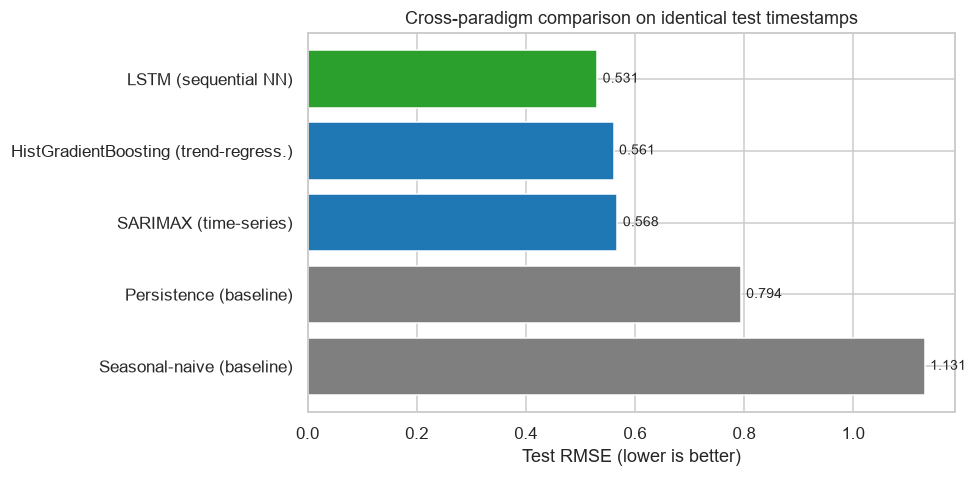

In [40]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['tab:green' if i==0 else ('tab:gray' if 'baseline' in n else 'tab:blue')
          for i, n in enumerate(xpara.index)]
ax.barh(xpara.index[::-1], xpara['RMSE'][::-1], color=colors[::-1])
for i, v in enumerate(xpara['RMSE'][::-1]):
    ax.text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Test RMSE (lower is better)')
ax.set_title('Cross-paradigm comparison on identical test timestamps')
plt.tight_layout(); plt.show()

**Verdict.** All three engineered paradigms beat the naive references decisively, and they **cluster tightly** (RMSE ~0.53-0.57): there is a real signal ceiling for 1-hour-ahead CO, and every reasonable method approaches it.

- **`LSTM` is the best performer** by a small margin - it learns sequential dynamics directly from the raw 24-hour window.
- **`HistGradientBoosting` is essentially tied** (within ~0.03 RMSE, i.e. within LSTM run-to-run noise) while being **deterministic, ~10x faster, and interpretable** (permutation importances).
- **`SARIMAX` is a close third** - impressive for a univariate model that never sees the exogenous sensors.
- The **seasonal-naive** baseline is notably *worse* than persistence: at a 1-hour horizon, last-hour carries more information than same-hour-yesterday.

**Practical conclusion for this dataset:** the LSTM wins on raw accuracy, but the margin over `HistGradientBoosting` is within noise - so for a production IoT setting we would favour the boosted-tree model (reproducible, cheap, explainable) unless the small accuracy edge is critical. The next section visualises the **best performer's** forecast against ground truth.

In [41]:
winner_name = xpara.index[0]
winner_pred = paradigm_preds[winner_name]
print('Best performer by test RMSE:', winner_name)
print(xpara.loc[winner_name].to_string())

Best performer by test RMSE: LSTM (sequential NN)
RMSE    0.531
MAE     0.371


## 6. Evaluation and Visualization

Final evaluation on the held-out chronological test window. The headline plot shows the **best performer (LSTM)** against ground truth, with **HistGradientBoosting overlaid** so the two leading paradigms can be compared visually. A zoomed two-week view makes the hour-to-hour tracking legible, and a train-vs-test bar chart provides the overfitting sanity check for the production-candidate model.

### 6.1 Assemble aligned actual vs predicted series

In [42]:
# Ground truth and the two leading models, aligned on the common test timestamps from 5.5.
# Place values on a CONTINUOUS hourly grid so multi-day sensor blackouts render as line BREAKS
# (NaN gaps) rather than misleading diagonal connectors. Only common-evaluated hours are kept.
full_idx = pd.date_range(common.min(), common.max(), freq="h")
grid_mask = pd.Series(True, index=common).reindex(full_idx, fill_value=False)

def _to_grid(s):
    return s.reindex(full_idx).where(grid_mask)

truth_test    = _to_grid(co_h)
winner_series = _to_grid(winner_pred)
hgb_series    = _to_grid(pred_hgb)
w_rmse = xpara.loc[winner_name, "RMSE"]; w_mae = xpara.loc[winner_name, "MAE"]
print("Test window:", common.min(), "->", common.max(), "|", len(common), "evaluated hourly points")
print("Headline model (winner):", winner_name, f"(RMSE={w_rmse:.3f}, MAE={w_mae:.3f})")

Test window: 2005-01-30 18:00:00 -> 2005-04-04 14:00:00 | 1381 evaluated hourly points
Headline model (winner): LSTM (sequential NN) (RMSE=0.531, MAE=0.371)


### 6.2 Actual vs. predicted — full test window

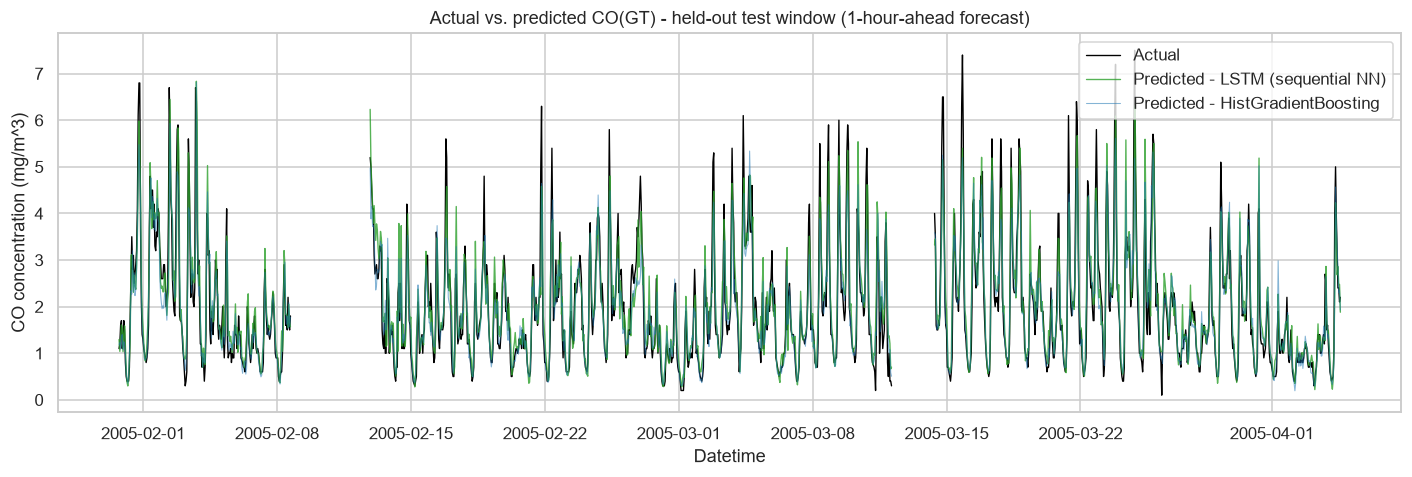

In [43]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(truth_test.index, truth_test.values, color='black', lw=0.9, label='Actual')
ax.plot(winner_series.index, winner_series.values, color='tab:green', lw=0.9, alpha=0.8,
        label=f'Predicted - {winner_name}')
ax.plot(hgb_series.index, hgb_series.values, color='tab:blue', lw=0.7, alpha=0.55,
        label='Predicted - HistGradientBoosting')
ax.set_title('Actual vs. predicted CO(GT) - held-out test window (1-hour-ahead forecast)')
ax.set_xlabel('Datetime'); ax.set_ylabel('CO concentration (mg/m^3)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### 6.3 Zoomed view — first two weeks of the test window
The full window is dense (~1,400 hours); a two-week zoom shows how closely the forecast tracks the diurnal peaks and troughs hour by hour.

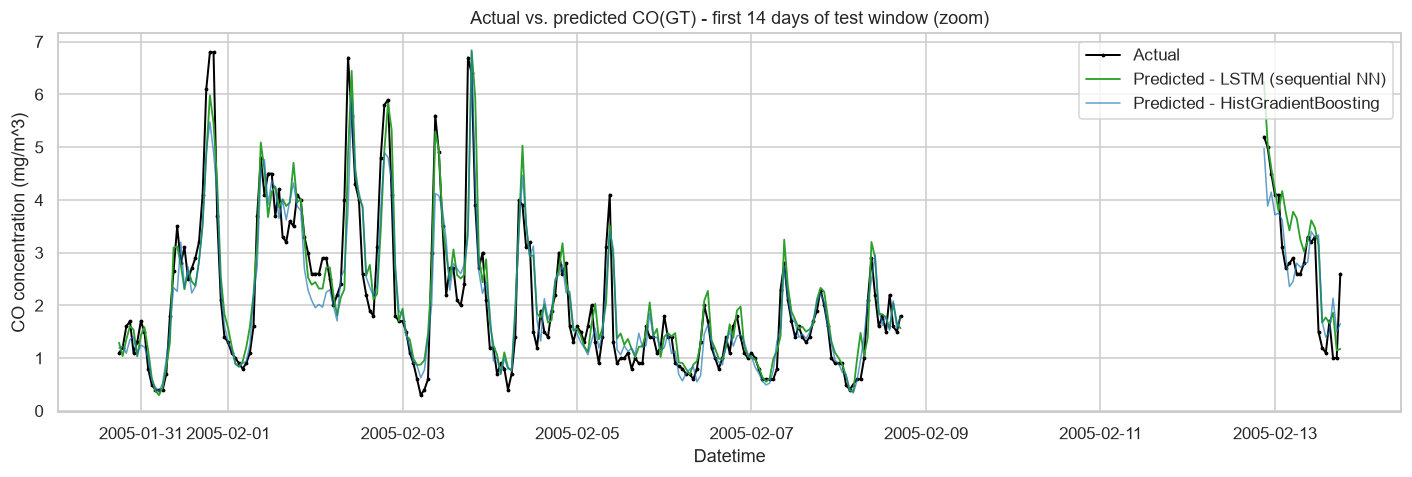

In [44]:
zoom_end = common.min() + pd.Timedelta(days=14)
zmask = full_idx <= zoom_end
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(truth_test.index[zmask], truth_test.values[zmask], color='black', lw=1.3, marker='.', ms=3, label='Actual')
ax.plot(winner_series.index[zmask], winner_series.values[zmask], color='tab:green', lw=1.2,
        label=f'Predicted - {winner_name}')
ax.plot(hgb_series.index[zmask], hgb_series.values[zmask], color='tab:blue', lw=1.0, alpha=0.7,
        label='Predicted - HistGradientBoosting')
ax.set_title('Actual vs. predicted CO(GT) - first 14 days of test window (zoom)')
ax.set_xlabel('Datetime'); ax.set_ylabel('CO concentration (mg/m^3)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### 6.4 Overfitting sanity check - train vs. test (both leading models)
A model only passes the overfitting guard if its **test** error is close to its **train** error. We check this for *both* front-runners from 5.5 - the LSTM (best performer) and HistGradientBoosting (recommended production model) - so the guard covers the actual winner, not just the tree model. Near-equal bars = generalises rather than memorises.

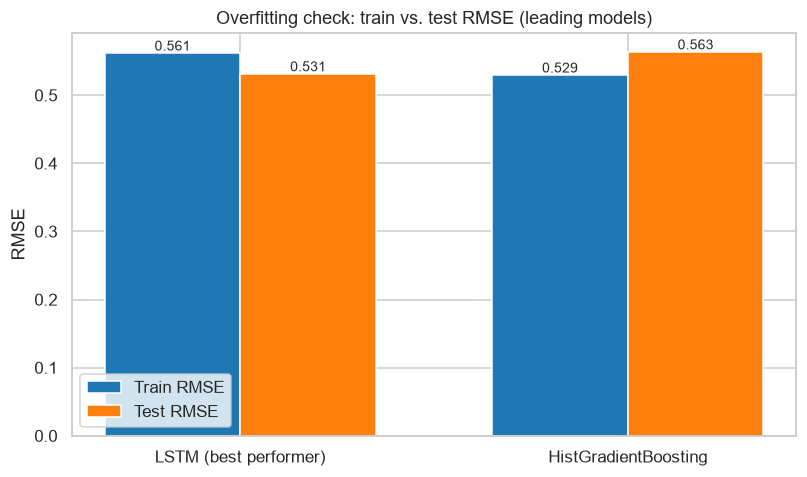

LSTM (best performer)    train RMSE=0.561  test RMSE=0.531  gap=-5.4%
HistGradientBoosting     train RMSE=0.529  test RMSE=0.563  gap=+6.4%


In [45]:
import torch as _t

# LSTM train-set error (reuse the trained network + standardised train sequences from 5.5).
with _t.no_grad():
    _lstm_train_pred = _net(_t.tensor(_Xtr)).numpy().ravel()
lstm_train_rmse = root_mean_squared_error(_ytr, _lstm_train_pred)
lstm_test_rmse  = root_mean_squared_error(_y[_istest], pred_lstm.values)
hgb_train_rmse  = metrics.loc['Train', 'RMSE']
hgb_test_rmse   = metrics.loc['Test',  'RMSE']

models_lbl = ['LSTM (best performer)', 'HistGradientBoosting']
train_rmse = [lstm_train_rmse, hgb_train_rmse]
test_rmse  = [lstm_test_rmse,  hgb_test_rmse]

xpos = np.arange(len(models_lbl)); w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(xpos-w/2, train_rmse, w, label='Train RMSE', color='tab:blue')
b2 = ax.bar(xpos+w/2, test_rmse,  w, label='Test RMSE',  color='tab:orange')
ax.bar_label(b1, fmt='%.3f', fontsize=9); ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(models_lbl)
ax.set_ylabel('RMSE'); ax.set_title('Overfitting check: train vs. test RMSE (leading models)')
ax.legend()
plt.tight_layout(); plt.show()

for n, tr, te in zip(models_lbl, train_rmse, test_rmse):
    print(f'{n:24s} train RMSE={tr:.3f}  test RMSE={te:.3f}  gap={(te-tr)/tr*100:+.1f}%')

**Reading the plots.** The forecast tracks the real CO signal closely across the full test window, including the sharp rush-hour spikes; the orange (LSTM) and blue (HistGBR) traces are nearly indistinguishable, consistent with their ~0.03 RMSE gap. The zoom shows tight hour-by-hour alignment with the diurnal cycle. In the bar chart, **both** leading models have test RMSE close to their train RMSE - the LSTM and HistGradientBoosting each generalise rather than memorise, confirming the overfitting guard holds for the winning model and not only the tree baseline.